In [6]:
import numpy as np

In [7]:
def data_generator(n=10_000, bad_rate=0.05, seed=37):
    np.random.seed(seed)
    
    nbad = int(n*bad_rate)
    ngood = n - nbad
    
    non_default = np.random.normal(650, 100, ngood).astype(int)
    default = np.random.normal(500, 120, nbad).astype(int)
    
    non_default = np.c_[non_default, np.zeros_like(non_default)]
    default = np.c_[default, np.ones_like(default)]
    
    output = np.vstack((non_default, default))
    np.random.shuffle(output)
    
    return output
data = data_generator(n=10_000)
data = data[np.argsort(data[:, 0], axis=0)]

In [8]:
data

array([[ 88,   1],
       [108,   1],
       [146,   1],
       ...,
       [980,   0],
       [981,   0],
       [997,   0]])

In [9]:
thresholds = np.where(np.diff(data[:, 0]))[0]

In [10]:
thresholds

array([   0,    1,    2,    3,    4,    7,    8,    9,   10,   11,   12,
         15,   16,   17,   19,   20,   22,   23,   24,   25,   26,   28,
         30,   32,   33,   34,   36,   37,   38,   39,   41,   43,   44,
         45,   46,   48,   49,   50,   51,   52,   53,   57,   60,   61,
         62,   63,   65,   66,   67,   68,   69,   70,   71,   72,   73,
         75,   76,   79,   80,   82,   83,   84,   86,   88,   89,   92,
         93,   94,   97,   98,   99,  101,  104,  105,  106,  108,  111,
        117,  118,  122,  124,  126,  130,  133,  135,  137,  139,  140,
        143,  145,  148,  150,  153,  157,  161,  164,  168,  169,  174,
        177,  178,  179,  184,  190,  192,  198,  201,  204,  208,  210,
        214,  215,  220,  222,  224,  229,  235,  239,  244,  246,  252,
        254,  260,  263,  270,  272,  276,  280,  287,  293,  295,  298,
        303,  304,  314,  318,  320,  322,  326,  329,  333,  339,  341,
        347,  351,  357,  365,  369,  377,  382,  3

In [11]:
thresholds = np.r_[thresholds, data[:, 0].size - 1]

In [12]:
thresholds

array([   0,    1,    2,    3,    4,    7,    8,    9,   10,   11,   12,
         15,   16,   17,   19,   20,   22,   23,   24,   25,   26,   28,
         30,   32,   33,   34,   36,   37,   38,   39,   41,   43,   44,
         45,   46,   48,   49,   50,   51,   52,   53,   57,   60,   61,
         62,   63,   65,   66,   67,   68,   69,   70,   71,   72,   73,
         75,   76,   79,   80,   82,   83,   84,   86,   88,   89,   92,
         93,   94,   97,   98,   99,  101,  104,  105,  106,  108,  111,
        117,  118,  122,  124,  126,  130,  133,  135,  137,  139,  140,
        143,  145,  148,  150,  153,  157,  161,  164,  168,  169,  174,
        177,  178,  179,  184,  190,  192,  198,  201,  204,  208,  210,
        214,  215,  220,  222,  224,  229,  235,  239,  244,  246,  252,
        254,  260,  263,  270,  272,  276,  280,  287,  293,  295,  298,
        303,  304,  314,  318,  320,  322,  326,  329,  333,  339,  341,
        347,  351,  357,  365,  369,  377,  382,  3

In [13]:
tps = np.cumsum(data[:, 1])[thresholds]
fps = np.cumsum(1 - data[:, 1])[thresholds]

In [14]:
tpr = tps / tps[-1]
fpr = fps / fps[-1]
auc = np.sum(np.r_[0, np.diff(fpr)] * tpr).round(4).item()
gini = 2*auc - 1

Text(0.5, 0.95, 'gini=0.6792')

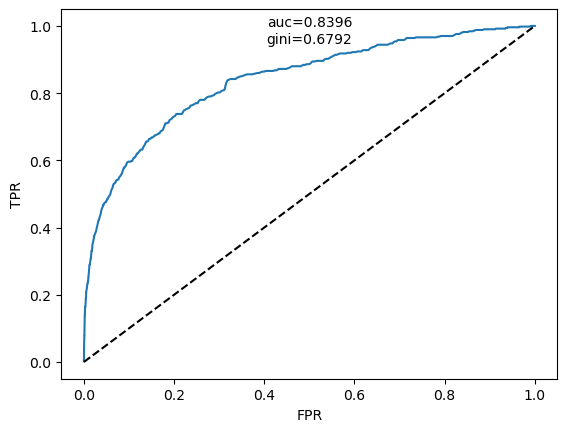

In [15]:
import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot([0,1], [0,1], 'k--')
plt.text(x=0.5, y = 1, s=f"{auc=}", ha='center')
plt.text(x=0.5, y = 0.95, s=f"{gini=}", ha='center')

(array([ 2.,  0.,  2.,  1.,  0.,  4., 10., 13., 21., 21., 22., 25., 43.,
        33., 39., 40., 40., 44., 32., 36., 12., 20., 14.,  9.,  8.,  4.,
         2.,  2.,  0.,  1.]),
 array([ 88.        , 114.46666667, 140.93333333, 167.4       ,
        193.86666667, 220.33333333, 246.8       , 273.26666667,
        299.73333333, 326.2       , 352.66666667, 379.13333333,
        405.6       , 432.06666667, 458.53333333, 485.        ,
        511.46666667, 537.93333333, 564.4       , 590.86666667,
        617.33333333, 643.8       , 670.26666667, 696.73333333,
        723.2       , 749.66666667, 776.13333333, 802.6       ,
        829.06666667, 855.53333333, 882.        ]),
 <BarContainer object of 30 artists>)

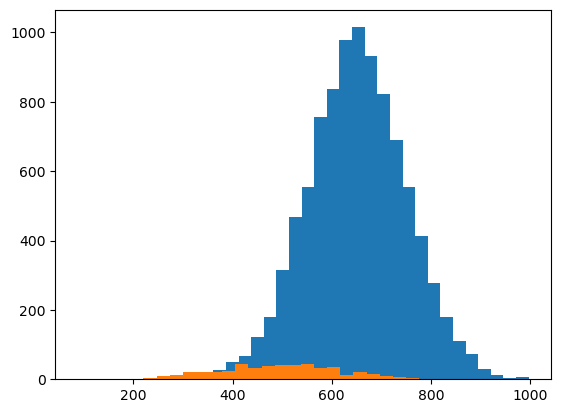

In [16]:
score = data[:, 0]
actual = data[:, 1]

plt.hist(data[np.where(data[:, 1] == 0)[0], 0], bins=30)
plt.hist(data[np.where(data[:, 1] == 1)[0], 0], bins=30)

In [17]:
import pandas as pd
import sqlite3

try:
    conn = sqlite3.connect('credit_data.db')
except Exception:
    pass

pd.DataFrame(data).to_csv('credit_score.csv', header=False, index=False)
pd.DataFrame(data).to_sql('credit_data', conn, index=False, if_exists='replace')

10000